In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pathlib import Path
import pandas as pd

# Local files/code
import src.data_preprocessing.text_preprocessing as text_pre
import src.config as config
from src.data_preprocessing.USDA_processing import embed_USDA_data, make_USDA_plant_sheets_dataframe
from sklearn.model_selection import train_test_split




In [30]:
import os
##Read in image dataset
train_image_path = Path.cwd() / 'data' / 'plantseg' / 'images' / 'train'
train_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' / 'train_binarized'

test_image_path = Path.cwd() / 'data' / 'plantseg' / 'images' / 'test'
test_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' / 'test_binarized'

val_image_path = Path.cwd() / 'data' / 'plantseg' / 'images' / 'val'
val_mask_path = Path.cwd() / 'data' / 'plantseg' / 'annotations' / 'val_binarized'
##train_mask_path = "./data/plantseg/annotations/train"
##
##print(train_image_path)
##
##train_img_list = sorted([os.path.join(train_image_path, f) for f in os.listdir(train_image_path) if f.endswith('.jpg')])
##train_mask_list = sorted([os.path.join(train_mask_path, f) for f in os.listdir(train_mask_path) if f.endswith('.png')])

In [4]:
print(train_image_path)

for folder in train_image_path.iterdir():
    if folder.name.endswith('_binarized'):
        continue
    binary_path = Path(str(folder) + '_binarized')
    binary_path.mkdir(parents=True, exist_ok=True)
    

    for image in folder.iterdir():
        #Read in the mask
        mask = cv2.imread(image, cv2.IMREAD_GRAYSCALE)

        if mask.ndim == 3:
            mask = mask[..., 0]

        mask = (mask > 0).astype(np.uint8) * 255
        mask = mask[..., np.newaxis]

        out_file = binary_path / (image.stem + '.png')
        cv2.imwrite(str(out_file), mask)
  

    
#for file in train_mask_path.:
#    print(file)

c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\images\train


NotADirectoryError: [WinError 267] The directory name is invalid: 'c:\\Users\\Kyler_Code\\Desktop\\PlantQA\\data\\plantseg\\images\\train\\apple_black_rot_1.jpg'

In [4]:
train_img_list = sorted([os.path.join(train_image_path, f) for f in os.listdir(train_image_path) if f.endswith('.jpg')])
train_mask_list = sorted([os.path.join(train_mask_path, f) for f in os.listdir(train_mask_path) if f.endswith('.png')])

c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\images\train\banana_bunchy_top_Baidu_0057.jpg
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\banana_bunchy_top_Baidu_0057.png


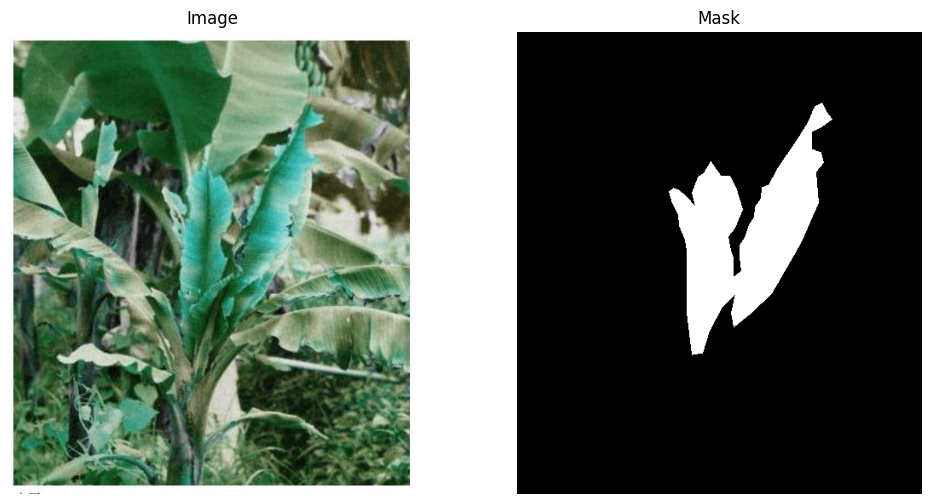

In [31]:
print(train_img_list[400])
print(train_mask_list[400])
#read in some images
img = cv2.imread(train_img_list[400])
mask = cv2.imread(train_mask_list[400])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask[:, :, 0] if mask.ndim == 3 else mask, cmap="gray")
ax[1].set_title("Mask")
ax[1].axis("off")
plt.show()

In [6]:
#pull in healthy data from plantExpertVQA
# preprocess (not tokenize) the training, testing, and validation datasets

plant_expert_vqa_TRAIN= text_pre.load_csv(config.Data.PlantExpertVQA.TRAIN_FILE)
plant_expert_vqa_TEST= text_pre.load_csv(config.Data.PlantExpertVQA.TEST_FILE)
plant_expert_vqa_VAL= text_pre.load_csv(config.Data.PlantExpertVQA.VALIDATION_FILE)

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    config.Data.PlantExpertVQA.TEXT_COLUMNS,
    config.Data.PlantExpertVQA.COLUMNS_TO_REMOVE,
    config.Data.PlantExpertVQA.NA_FILL,
    ["image_path"],
    config.Data.PlantExpertVQA.ROOT,
)
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    config.Data.PlantExpertVQA.TEXT_COLUMNS,
    config.Data.PlantExpertVQA.COLUMNS_TO_REMOVE,
    config.Data.PlantExpertVQA.NA_FILL,
    ["image_path"],
    config.Data.PlantExpertVQA.ROOT,
)

text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    config.Data.PlantExpertVQA.TEXT_COLUMNS,
    config.Data.PlantExpertVQA.COLUMNS_TO_REMOVE,
    config.Data.PlantExpertVQA.NA_FILL,
    ["image_path"],
    config.Data.PlantExpertVQA.ROOT,
)

12:37:38 [DEBUG   ]: [load_csv] Successfully loaded C:\Users\Kyler_Code\Desktop\PlantQA\data\PlantExpertVQA\data\train.csv into dataframe


c:\Users\Kyler_Code\Desktop\PlantQA\src\data_preprocessing\text_preprocessing.py:44: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


12:37:38 [DEBUG   ]: [load_csv] Successfully loaded C:\Users\Kyler_Code\Desktop\PlantQA\data\PlantExpertVQA\data\test.csv into dataframe
12:37:38 [DEBUG   ]: [load_csv] Successfully loaded C:\Users\Kyler_Code\Desktop\PlantQA\data\PlantExpertVQA\data\val.csv into dataframe


In [32]:

test_healthy = plant_expert_vqa_TEST[plant_expert_vqa_TEST['category'] == 'healthy']

#Choose a random 500 images
test_healthy = test_healthy.sample(n=400, random_state=42)



In [33]:
train_img, temp_img = train_test_split(test_healthy, test_size=0.3, random_state=42)
val_img, test_img = train_test_split(temp_img, test_size=0.50, random_state=42)

In [19]:
print(train_img)

                                       qa_id              image_id  \
100755  f93a87da-c700-46d6-8add-bfdcdb005154  cce9c34aceec84c3.jpg   
126497  1c5840b4-29e1-49f7-b2c8-4ac33b014cd9      image_020603.JPG   
98172   c0f12b66-a207-4f85-bc6d-bd548fd43434  6e4ca54f2fabae3a.jpg   
96872   477da7ac-a6a6-4a02-96f8-7567d1b35795  1d50c1ff9fead460.jpg   
104246  c0c90fae-162e-4cca-ab7c-b71c898d6298  a36bc7f816122a50.jpg   
...                                      ...                   ...   
107384  188d3705-ad0a-487e-95dc-c947e97cd16e  91823dc70468e9cc.jpg   
100226  84d20c78-f33a-4618-b340-673cb8782911  79c0679e18ba4ae5.jpg   
102919  587223d0-6c04-40c3-b437-cdb891fbba3b  0a84e30bf68e822b.jpg   
104406  0901ab8a-c506-44a6-82e9-26e04782bf0f  a78ffc40db9accf2.jpg   
107789  9b2dd5bf-8482-457c-8410-8ccb2db9422d  19a8a40c6e46af0a.jpg   

                                               image_path          crop  \
100755  C:\Users\Kyler_Code\Desktop\PlantQA\data\Plant...          corn   
126497  C

In [34]:
#train image save_path

for i, r in train_img.iterrows():
    #save each image again into the plantseg data
    stem = Path(r['image_id']).stem
    mask_save = train_mask_path / str(stem + '.png')
    img_save  = train_image_path / r['image_id']
    print(mask_save)
    if mask_save.exists() and img_save.exists():
        continue
    img_path = config.Data.PlantExpertVQA.ROOT / r['image_path']
    img = cv2.imread(img_path)
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask = mask[..., np.newaxis]
    cv2.imwrite(str(mask_save), mask)
    cv2.imwrite(str(img_save), img)

for i, r in test_img.iterrows():
    #save each image again into the plantseg data
    stem = Path(r['image_id']).stem
    mask_save = test_mask_path / str(stem + '.png')
    img_save  = test_image_path / r['image_id']
    print(mask_save)
    if mask_save.exists() and img_save.exists():
        continue
    img_path = config.Data.PlantExpertVQA.ROOT / r['image_path']
    img = cv2.imread(img_path)
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask = mask[..., np.newaxis]
    cv2.imwrite(str(mask_save), mask)
    cv2.imwrite(str(img_save), img)

for i, r in val_img.iterrows():
    #save each image again into the plantseg data
    stem = Path(r['image_id']).stem
    mask_save = val_mask_path / str(stem + '.png')
    img_save  = val_image_path / r['image_id']
    print(mask_save)
    if mask_save.exists() and img_save.exists():
        continue
    img_path = config.Data.PlantExpertVQA.ROOT / r['image_path']
    img = cv2.imread(img_path)
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask = mask[..., np.newaxis]
    cv2.imwrite(str(mask_save), mask)
    cv2.imwrite(str(img_save), img)
    

    

c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\cce9c34aceec84c3.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\image_020603.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\6e4ca54f2fabae3a.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\1d50c1ff9fead460.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\a36bc7f816122a50.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\612d574d25507d46.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\image_027199.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\c7b901f4f285b4a0.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\image_031641.png
c:\Users\Kyler_Code\Desktop\PlantQA\data\plantseg\annotations\train_binarized\3d846908178d8405.png
c:\Users\Kyler_Code\De

In [ ]:
#begin training the UNet

